# Customer Segmentation Using K-Means Clustering

## 1.Data Preparation & Import
### 1.1.Import Required Libraries
---

In [ ]:
# 1. General Utilities & Data Handling
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import squarify

# 2. Machine Learning & Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 3. Lifetime Value (CLV) Modeling
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# 4. Settings & Configurations
from mpl_toolkits.mplot3d import Axes3D
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# 6. Visualization Theme
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1.2.Loading the data Set
---

In [2]:
# Define file paths
local_path = "online_retail_II.csv"

# Load dataset
if os.path.exists(local_path):
    df = pd.read_csv(local_path, encoding="ISO-8859-1")
    print(f"Dataset loaded successfully! Shape: {df.shape}")
else:
    raise FileNotFoundError(
        "Dataset not found!"
    )

Dataset loaded successfully! Shape: (1067371, 8)


## 2.Exploratory Data Analysis (EDA)
---

In [3]:
def check_df(df, head=10):
    print(f"\033[1m{'*' * 20} SHAPE {'*' * 20}\033[0m")
    print(df.shape)
    print(f"\033[1m{'*' * 20} TYPES {'*' * 20}\033[0m")
    print(df.dtypes)
    print(f"\033[1m{'*' * 20} HEAD {'*' * 20}\033[0m")
    print(df.head(head))
    print(f"\033[1m{'*' * 20} TAIL {'*' * 20}\033[0m")
    print(df.tail(head))
    print(f"\033[1m{'*' * 20} MISSING VALUES {'*' * 20}\033[0m")
    print(df.replace(r'^\s*$', np.nan, regex=True).isnull().sum())
    print(f"\033[1m{'*' * 20} MISSING VALUE PERCENTS {'*' * 20}\033[0m")
    print((df.replace(r'^\s*$', np.nan, regex=True).isnull().sum()/len(df)*100).sort_values(ascending=False))
    print(f"\033[1m{'*' * 20} DUPLICATED VALUES {'*' * 20}\033[0m")
    print(df.duplicated().sum())
    print(f"\033[1m{'*' * 20} UNIQUE VALUES {'*' * 20}\033[0m")
    print(df.nunique())
    print(f"\033[1m{'*' * 20} STATISTICAL SUMMARY OF NUMERICAL FEATURES {'*' * 20}\033[0m")
    print(df.describe().T)
    print(f"\033[1m{'*' * 20} STATISTICAL SUMMARY OF CATEGORICAL FEATURES {'*' * 20}\033[0m")
    print(df.describe(include=['object']).T)
check_df(df,10)

******************** SHAPE ********************
(1067371, 8)
******************** TYPES ********************
Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object
******************** HEAD ********************
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
5  489434     22064           PINK DOUGHNUT TRINKET POT         24   
6  489434     21871                  SAVE THE PLANET MUG        24   
7  489434     21523   FANCY FONT HOME SWEET HOME DOORMAT        10   
8  489435     22

### 2.1.Data Preprocessing & Feature Engineering
---

In [4]:
def preprocess_retail(df):
    df = df.drop_duplicates()
    df = df.dropna(subset=["Customer ID"])
    df["Customer ID"] = df["Customer ID"].astype(int)
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
    df = df[(df["Quantity"] > 0) & (df["Price"] > 0)]
    df["TotalPrice"] = df["Quantity"] * df["Price"]
    df = df[~df["Invoice"].str.contains("C", na=False)]
    df["StockCode"] = df["StockCode"].astype(str)
    df = df[(
    (df["StockCode"].str.match(r"^\d{5}$")) | 
    (df["StockCode"].str.match(r"^\d{5}[a-zA-Z]+$")) | 
    (df["StockCode"].str.match(r"^PADS$")))]
    df["Description"] = df["Description"].fillna("Unknown")
    return df
df = preprocess_retail(df)

print(f"Processed dataset shape: {df.shape}")

Processed dataset shape: (776594, 10)


* Removed duplicate transaction records to eliminate redundancy and ensure data integrity.
* Dropped records with missing **Customer ID** values to maintain reliable customer-level analysis.
* Converted **Customer ID** to integer format for consistency and easier processing.
* Transformed **InvoiceDate** into datetime format for temporal analysis.
* Created **InvoiceMonth** feature from invoice dates to enable monthly trend and cohort analysis.
* Filtered out transactions with non-positive **Quantity** values to remove invalid purchase records.
* Filtered out transactions with non-positive **Price** values to eliminate erroneous pricing entries.
* Engineered **TotalPrice** feature by multiplying **Quantity** × **Price** to calculate transaction-level revenue.
* Removed cancelled transactions by excluding invoices containing cancellation indicator ("C").
* Converted **StockCode** to string format for standardized product code processing.
* Applied regex-based validation to retain only legitimate/valid **StockCode** patterns.
* Filled missing **Description** values with "Unknown" to preserve dataset completeness.

In [5]:
check_df(df)

******************** SHAPE ********************
(776594, 10)
******************** TYPES ********************
Invoice                 object
StockCode               object
Description             object
Quantity                 int64
InvoiceDate     datetime64[ns]
Price                  float64
Customer ID              int64
Country                 object
InvoiceMonth         period[M]
TotalPrice             float64
dtype: object
******************** HEAD ********************
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   
5  489434     22064           PINK DOUGHNUT TRINKET POT         24   
6  489434     21871           

## 3. RFM Analysis and Scoring 
---
This section calculates the RFM (Recency, Frequency, Monetary) metrics for each customer to understand their purchasing behavior. We define Recency as days since the last purchase, Frequency as the number of purchases, and Monetary as the total spending.

### 3.1.RFM Feature Calculation
---

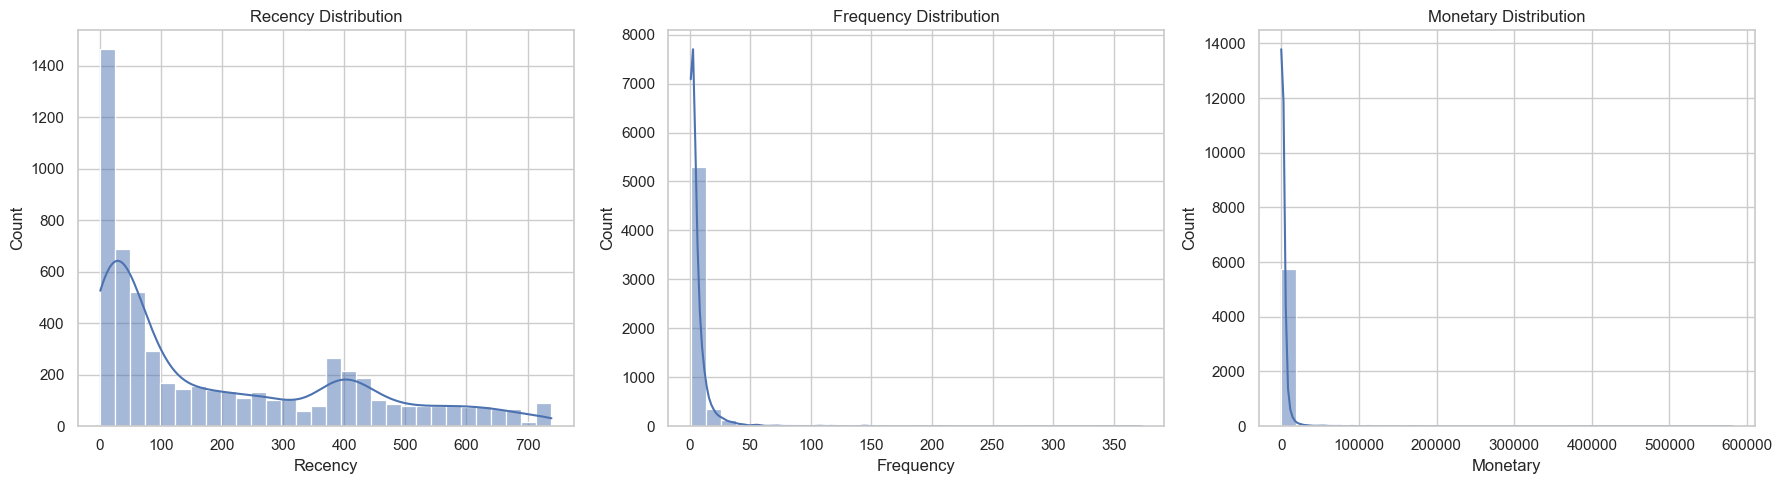

In [ ]:
# Define reference date as one day after the latest transaction
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Aggregate transaction data at customer level
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,   # Recency : less is better 
    "Invoice": "nunique",                                       # Frequency : more is better
    "TotalPrice": "sum"                                         # Monetary : more is better
})

# Rename RFM columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Standardize index name
rfm.index.name = "CustomerID"

# RFM Feature Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(rfm):
    sns.histplot(
        rfm[col],
        bins=30,
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()



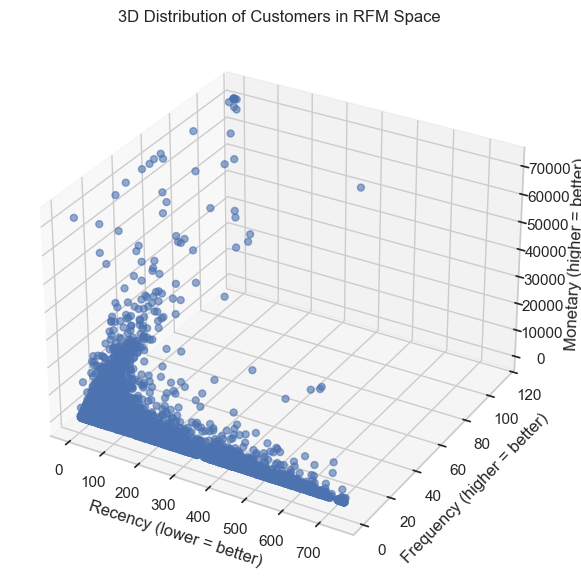

In [ ]:
# 3D Visualization of RFM 
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(rfm["Recency"], rfm["Frequency"], rfm["Monetary"], alpha=0.6, s=25)

# Axis labels
ax.set_xlabel("Recency (lower = better)")
ax.set_ylabel("Frequency (higher = better)")
ax.set_zlabel("Monetary (higher = better)")
ax.set_title("3D Distribution of Customers in RFM Space")

plt.show()

### 3.2.Outlier Detection and Capping for RFM Metrics
---

--- Recency Analizi ---
Result: No outliers detected in Recency.
------------------------------
--- Frequency Analizi ---
Result: No outliers detected in Frequency.
------------------------------
--- Monetary Analizi ---
Result: No outliers detected in Monetary.
------------------------------

RFM Summary Statistics After Outlier Capping:
             count     mean      std   min     25%     50%      75%       max
Recency   5852.000  200.198  208.510 1.000  25.000  95.000  379.000   739.000
Frequency 5852.000    6.081   10.012 1.000   1.000   3.000    7.000   113.500
Monetary  5852.000 2519.640 6279.083 2.950 339.575 856.020 2241.030 71509.723
Cluster   5852.000    2.626    1.183 1.000   2.000   3.000    4.000     4.000


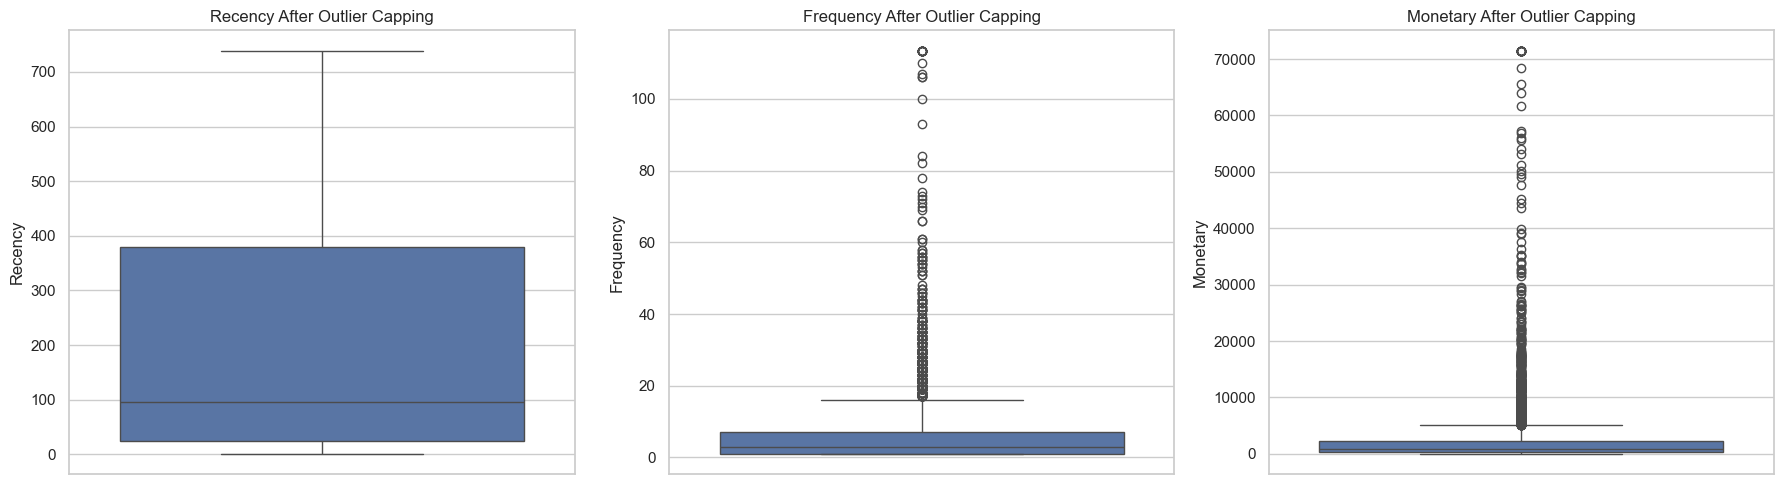

In [21]:
def outliers_iqr(df, columns):
    """
    Detects and caps outliers using modified IQR method
    based on 1st and 99th percentiles.
    """
    for col in columns:
        # Calculate modified IQR boundaries
        q1 = df[col].quantile(0.01)
        q3 = df[col].quantile(0.99)
        iqr = q3 - q1

        low_limit = q1 - 1.5 * iqr
        up_limit = q3 + 1.5 * iqr
        
        # Identify outliers
        outliers = df[(df[col] < low_limit) | (df[col] > up_limit)]
        
        print(f"--- {col} Analizi ---")
        if not outliers.empty:
            print(f"Detected outliers: {outliers.shape[0]}")
            print(f"Upper Limit: {up_limit:.2f} | Max Value Before Capping: {df[col].max():.2f}")
            
            # Apply capping
            df.loc[df[col] < low_limit, col] = low_limit
            df.loc[df[col] > up_limit, col] = up_limit
            
            print(f"Result: Outliers in {col} were successfully capped.")
        else:
            print(f"Result: No outliers detected in {col}.")
        print("-" * 30)
    return df

# Apply outlier capping to RFM metrics
rfm_cols = ["Recency", "Frequency", "Monetary"]
rfm = outliers_iqr(rfm, rfm_cols)

# Display post-capping summary statistics
print("\nRFM Summary Statistics After Outlier Capping:")
print(rfm.describe().T)

# Boxplots After Outlier Capping
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(rfm_cols):
    sns.boxplot(y=rfm[col], ax=axes[i])
    axes[i].set_title(f"{col} After Outlier Capping")

plt.tight_layout()
plt.show()


Due to the highly right-skewed nature of the Online Retail II dataset, a modified IQR method based on the 1st and 99th percentiles was applied instead of the traditional 25th/75th percentile approach. This prevents excessive trimming of legitimate high-value customers while still reducing the impact of extreme outliers for K-Means clustering.

### 3.2.1.Log Transformation and Feature Scaling
---
K-Means is distance-based, making it sensitive to feature scales. StandardScaler normalizes features to have zero mean and unit variance, ensuring equal contribution from each RFM dimension.

In [8]:
## Apply log transformation to reduce skewness
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p)

# Check skewness after transformation
print("Skewness After Log Transformation:")
print(rfm_log.skew())

# Standardize features for K-Means clustering
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Convert scaled array back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    index=rfm.index,
    columns=rfm_log.columns
)

# Preview scaled dataset
print("\nFirst 5 Rows of Scaled RFM Data:")
print(rfm_scaled.head())
print(rfm_scaled.describe().T)

Skewness After Log Transformation:
Recency     -0.486
Frequency    0.948
Monetary     0.204
dtype: float64

First 5 Rows of Scaled RFM Data:
            Recency  Frequency  Monetary
CustomerID                              
12346         0.861     -0.199     3.189
12347        -2.150      0.811     1.237
12348        -0.076      0.306     0.444
12349        -0.933     -0.199     1.025
12350         0.829     -1.062    -0.815
             count   mean   std    min    25%    50%   75%   max
Recency   5852.000 -0.000 1.000 -2.410 -0.764  0.074 0.957 1.385
Frequency 5852.000  0.000 1.000 -1.062 -1.062 -0.199 0.664 3.977
Monetary  5852.000  0.000 1.000 -3.962 -0.711 -0.038 0.663 3.189


Applied modified IQR-based outlier capping, log transformation, and feature scaling to normalize highly skewed RFM distributions and prepare the dataset for distance-based clustering. Post-transformation skewness values were reduced below acceptable thresholds, ensuring suitability for K-Means segmentation.

## 4. Optimal Cluster Selection
---

We use two methods to find the optimal number of clusters:
1. **Elbow Method:** Plot WCSS (Within-Cluster Sum of Squares) vs. number of clusters. The "elbow" point indicates optimal k.
2. **Silhouette Score:** Measures how similar objects are to their own cluster compared to other clusters. Higher is better.

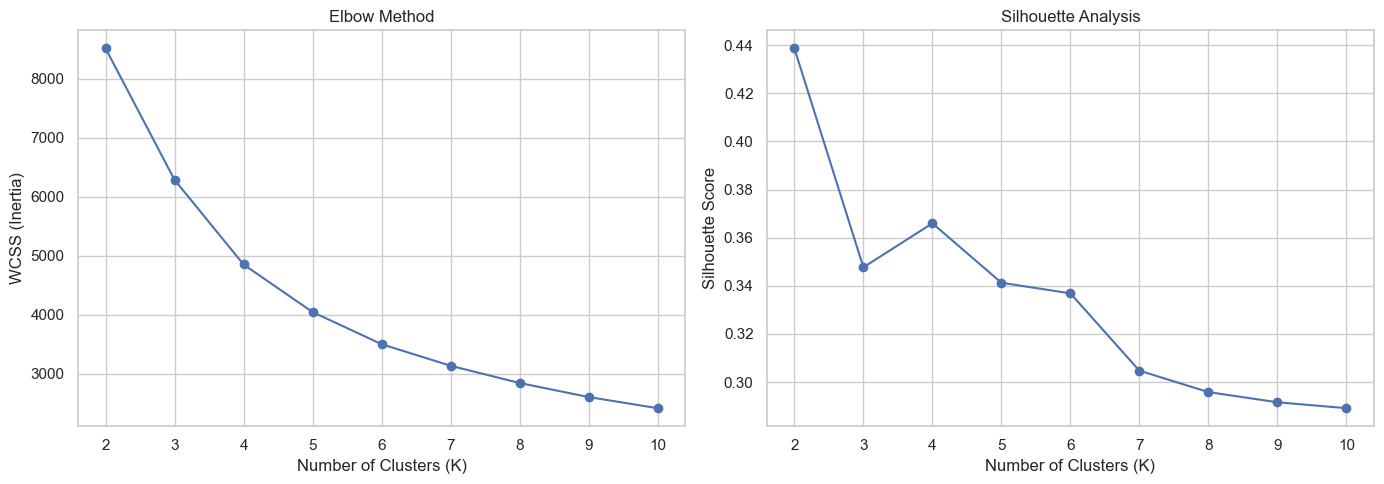

In [9]:
# Elbow Method + Silhouette Analysis
wcss = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)
    
    labels = kmeans.fit_predict(rfm_scaled)
    
    # Store WCSS (Within-Cluster Sum of Squares)
    wcss.append(kmeans.inertia_)
    
    # Store Silhouette Score
    silhouette_scores.append(
        silhouette_score(rfm_scaled, labels)
    )

# Visualization
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Elbow Method Plot
ax[0].plot(K_range, wcss, marker='o')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("WCSS (Inertia)")

# Silhouette Score Plot
ax[1].plot(K_range, silhouette_scores, marker='o')
ax[1].set_title("Silhouette Analysis")
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

### Optimal Cluster Selection
* The optimal number of clusters was determined by combining the **Elbow Method** and **Silhouette Analysis**. The Elbow Method was used to evaluate the within-cluster sum of squares (WCSS) across different cluster counts, identifying the point where the rate of decrease in inertia began to diminish. In parallel, Silhouette Analysis measured cluster cohesion and separation to assess clustering quality.
* Based on the joint evaluation of both metrics, **k = 4** was selected as the optimal number of clusters, as it provided a balanced trade-off between minimizing intra-cluster variance and maximizing inter-cluster separation. This configuration yielded interpretable and well-separated customer segments suitable for downstream RFM-based customer segmentation analysis.

## 5.Final K-Means Clustering Model
---
After determining the optimal number of clusters as k = 4, the final K-Means model was trained on the scaled RFM feature set. Cluster labels were assigned to each customer and re-indexed from a zero-based format to a one-based format for interpretability. Subsequently, descriptive statistics including mean, median, and customer count were calculated for each cluster to profile customer segments based on their Recency, Frequency, and Monetary characteristics.

In [10]:
k = 4

# Train final K-Means model
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Assign cluster labels
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Convert cluster labels from 0-based to 1-based indexing
rfm["Cluster"] = rfm["Cluster"] + 1

# Display customer count per cluster
print("Clustering Completed. Customer Distribution by Cluster:")
print(rfm["Cluster"].value_counts().sort_index())


Clustering Completed. Customer Distribution by Cluster:
Cluster
1    1453
2    1242
3    1198
4    1959
Name: count, dtype: int64


In [11]:
# Cluster Profiling Summary
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": ["mean", "median"],
    "Frequency": ["mean", "median"],
    "Monetary": ["mean", "median", "count"]
})

print("\nCluster Summary Statistics:")
print(cluster_summary)


Cluster Summary Statistics:
        Recency         Frequency        Monetary               
           mean  median      mean median     mean   median count
Cluster                                                         
1       228.060 185.000     5.050  4.000 1963.611 1450.040  1453
2        28.547  24.000     2.996  3.000  827.341  711.770  1242
3        27.806  16.000    18.217 13.000 8552.204 4879.185  1198
4       393.783 401.000     1.379  1.000  315.828  273.340  1959


### Customer Segmentation Results
* The K-Means clustering algorithm with **k = 4** successfully segmented customers based on their **RFM (Recency, Frequency, Monetary)** behavior. The resulting clusters exhibit clear and interpretable differences in purchasing behavior.
* **Cluster 3** represents the most valuable customer segment, characterized by high frequency and significantly higher monetary contribution with recent purchasing activity. **Cluster 2** consists of relatively active customers with moderate spending levels, indicating potential for loyalty development. **Cluster 1** includes customers with moderate spending but lower recency, suggesting reduced engagement and potential churn risk. Finally, **Cluster 4** represents low-value or inactive customers with high recency values and minimal purchasing behavior.
* These results demonstrate that RFM-based K-Means clustering effectively captures meaningful customer heterogeneity and enables actionable segmentation for targeted marketing strategies.

### 5.1. Cluster Naming Based on RFM Profiles
---

In [12]:
# First, compute cluster-level statistics
cluster_profile = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean"
})

# Normalize interpretation (important for rule logic)
recency_rank = cluster_profile["Recency"].rank(ascending=True)      # lower is better
frequency_rank = cluster_profile["Frequency"].rank(ascending=False)  # higher is better
monetary_rank = cluster_profile["Monetary"].rank(ascending=False)    # higher is better

# Create a scoring system
cluster_profile["Score"] = (
    recency_rank +
    frequency_rank +
    monetary_rank
)

# Function to assign names based on score
def assign_segment_name(row):
    score = row["Score"]
    if score <= 4:
        return "VIP Customers"         
    elif score <= 7:
        return "Loyal Customers"        
    elif score <= 9:
        return "Potential Loyalists"    
    elif score <= 12:
        return "At Risk/Lost"         
    else:
        return "Others"

# Apply naming
cluster_profile["Segment"] = cluster_profile.apply(assign_segment_name, axis=1)

# Map back to original dataframe
cluster_map = cluster_profile["Segment"].to_dict()
rfm["Segment"] = rfm["Cluster"].map(cluster_map)

# Display results
print("\nCluster-Level Segments:")
print(cluster_profile[["Recency", "Frequency", "Monetary", "Score", "Segment"]].sort_values("Score"))

print("\nCustomer Segment Distribution:")
print(rfm["Segment"].value_counts())


Cluster-Level Segments:
         Recency  Frequency  Monetary  Score              Segment
Cluster                                                          
3         27.806     18.217  8552.204  3.000        VIP Customers
1        228.060      5.050  1963.611  7.000      Loyal Customers
2         28.547      2.996   827.341  8.000  Potential Loyalists
4        393.783      1.379   315.828 12.000         At Risk/Lost

Customer Segment Distribution:
Segment
At Risk/Lost           1959
Loyal Customers        1453
Potential Loyalists    1242
VIP Customers          1198
Name: count, dtype: int64


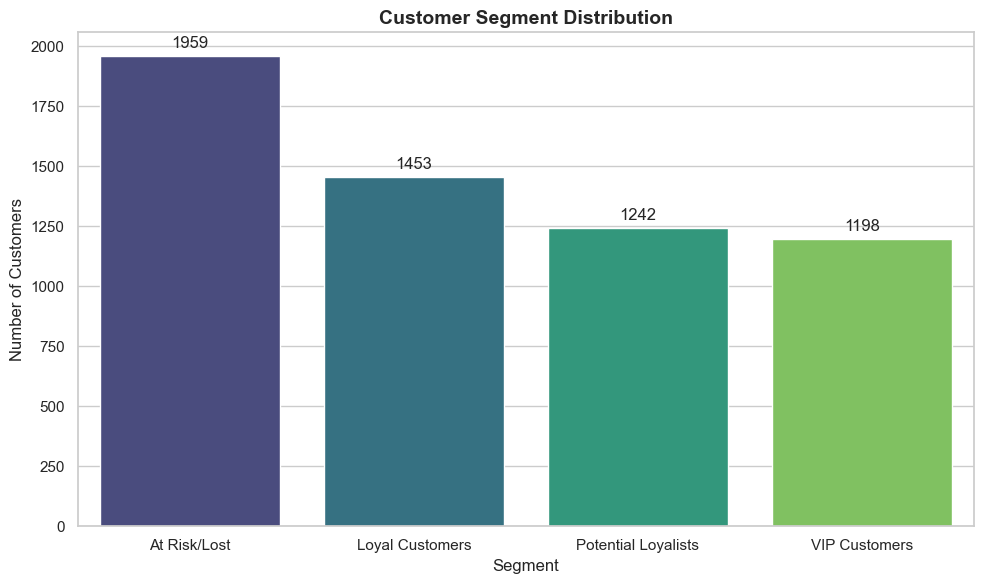

In [13]:
#Customer Segment Distribution

# Set the figure size for the plot
plt.figure(figsize=(10,6))
# Determine the order of segments based on customer count (highest to lowest)
order = rfm["Segment"].value_counts().index
# Create the count plot with a color palette
sns.countplot(data=rfm, x="Segment", order=order, palette="viridis")
# Set chart title and labels with custom font sizes and weight
plt.title("Customer Segment Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Segment", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

# Add numerical data labels on top of each bar for better readability
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    
plt.tight_layout()
plt.show()

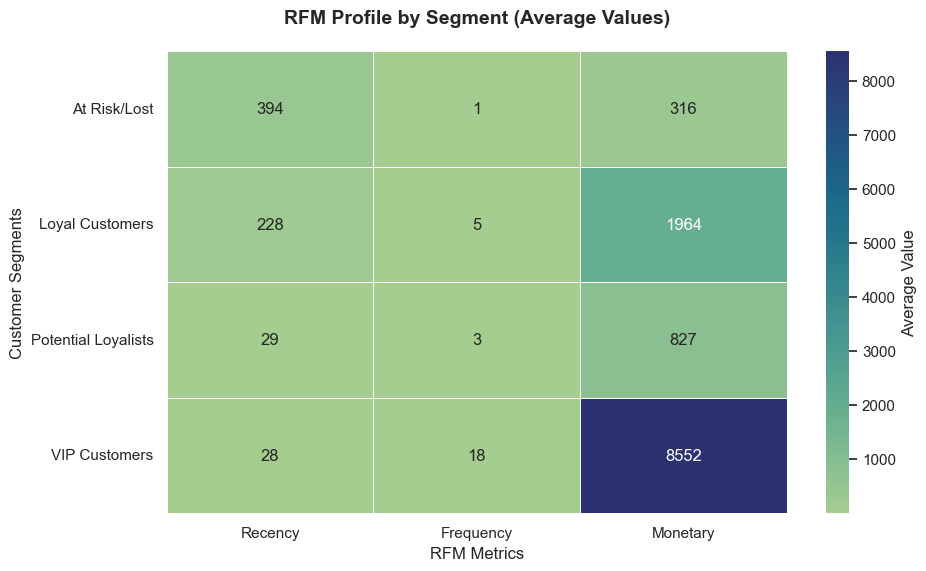

In [14]:
#The heatmap to visualize RFM characteristics
# Calculate the mean (average) values for each segment
segment_profile = rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()
# Set the figure size for the heatmap
plt.figure(figsize=(10, 6))

# Create the heatmap to visualize RFM characteristics
sns.heatmap(
    segment_profile,
    annot=True, 
    cmap="crest", 
    fmt=".0f", 
    linewidths=.5,
    cbar_kws={'label': 'Average Value'}
)

plt.title("RFM Profile by Segment (Average Values)", fontsize=14, pad=20, fontweight='bold')
plt.ylabel("Customer Segments", fontsize=12)
plt.xlabel("RFM Metrics", fontsize=12)
plt.show()

### Applying K-Means Clustering for Customer Segmentation 

We applied K-Means clustering on the standardized RFM data to automatically segment customers into meaningful groups.

1. K-Means with k=4:
   We used K=4 based on prior analysis (Elbow + Silhouette methods). The model assigns each customer to one of the 4 clusters based on Recency, Frequency, and Monetary value.

2. Cluster Profiling:
   We computed average RFM values for each cluster to interpret and label them based on customer behavior. Clusters were renamed accordingly:
   - Cluster 3 → VIP Customers
   - Cluster 1 → Loyal Customers
   - Cluster 2 → Potential Loyalists
   - Cluster 4 → At Risk/Lost

3. Visualizing Customer Segments:
   A scatter plot (Recency vs. Monetary) with color-coded segments illustrates how customer groups differ. This helps identify high-value customers and those needing attention at a glance.

## 6. Cluster Analysis and Business Insights
---
Let's analyze the characteristics of each customer segment to derive actionable business insights.

### 6.1.Principal Component Analysis (PCA)
---

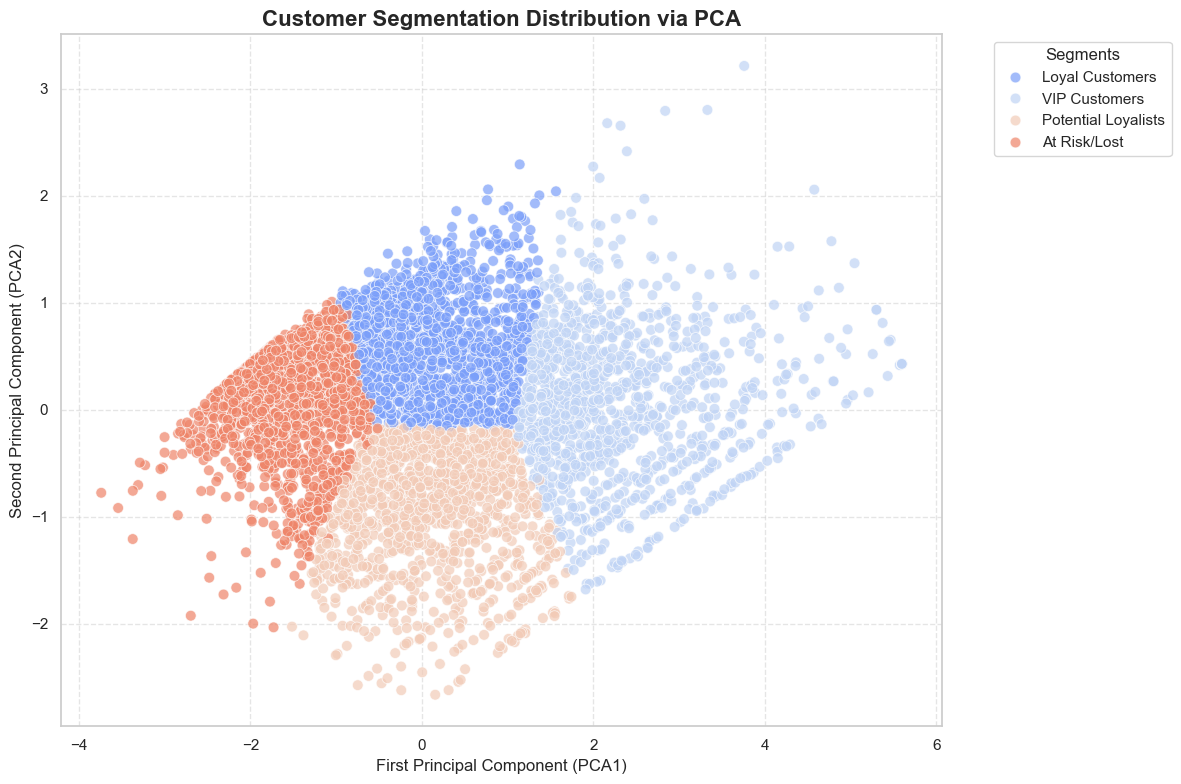

Total variance explained by PCA: 95.10%


In [15]:
# Initialize PCA to reduce the data from 3 dimensions to 2
# This allows us to visualize high-dimensional RFM data on a 2D plane
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=rfm_pca, columns=['PCA1', 'PCA2'], index=rfm.index)
pca_df['Segment'] = rfm['Segment']

# Visualization
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Segment', data=pca_df, 
                palette='coolwarm', s=60, alpha=0.7)

plt.title('Customer Segmentation Distribution via PCA', fontsize=16, fontweight='bold')
plt.xlabel('First Principal Component (PCA1)', fontsize=12)
plt.ylabel('Second Principal Component (PCA2)', fontsize=12)
plt.legend(title='Segments', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print the Total Explained Variance (Critical for scientific reporting)
# This percentage shows how much of the original information is preserved in 2D
explained_variance = sum(pca.explained_variance_ratio_) * 100
print(f"Total variance explained by PCA: {explained_variance:.2f}%")

### Customer Segmentation Distribution via Principal Component Analysis (PCA)

* The high-dimensional RFM dataset was projected onto a two-dimensional plane using PCA to evaluate the robustness of the clustering results. The scatter plot illustrates a clear spatial separation between the four identified segments: VIP Customers, Loyal Customers, Potential Loyalists, and At Risk/Lost. The distinct clustering observed along the First Principal Component (PCA1) suggests that the model effectively captures the variance in customer purchasing behavior and engagement levels. The minimal overlap between the clusters validates the efficacy of the K-Means algorithm in identifying statistically significant customer profiles, providing a reliable foundation for targeted marketing interventions.

### 6.2.CLV Prediction (BG/NBD & Gamma-Gamma)
---
* The integration of BG/NBD and Gamma-Gamma models provides a robust predictive framework for assessing long-term customer profitability. The results reveal a critical distinction between transactional loyalty (frequency) and financial value (monetary), allowing for a highly specialized resource allocation strategy.

In [16]:
# Data Preparation
# Define the reference date for analysis (usually 1 or 2 days after the last transaction)
today_date = df['InvoiceDate'].max() + dt.timedelta(days=2)

# Transforming transaction data into RFM summary format for Lifetimes models
# recency: duration between first and last purchase
# T: customer's age (duration between first purchase and analysis date)
# frequency: number of repeat purchases

clv_df = summary_data_from_transaction_data(df, 
                                            'Customer ID', 
                                            'InvoiceDate', 
                                            monetary_value_col='TotalPrice', 
                                            observation_period_end=today_date)

# Gamma-Gamma model requires frequency > 0 (repeat customers only)
# Also ensuring monetary value is positive to avoid calculation errors
clv_df = clv_df[clv_df['frequency'] > 0]
clv_df = clv_df[clv_df['monetary_value'] > 0]

# BG/NBD Model (Predicting Transaction Counts)
# penalizer_coef: applied to prevent overfitting during the optimization process
bgf = BetaGeoFitter(penalizer_coef=0.001)

bgf.fit(clv_df['frequency'], 
        clv_df['recency'], 
        clv_df['T'])

# Predict expected number of transactions for the next 3 months (12 weeks)
clv_df["expected_purc_3_month"] = bgf.predict(12, 
                                              clv_df['frequency'], 
                                              clv_df['recency'], 
                                              clv_df['T'])

# Gamma-Gamma Model (Predicting Average Profit/Value) ---
ggf = GammaGammaFitter(penalizer_coef=0.01)

ggf.fit(clv_df['frequency'], clv_df['monetary_value'])

# Calculate the conditional expected average profit per transaction
clv_df["expected_average_profit"] = ggf.conditional_expected_average_profit(clv_df['frequency'],
                                                                           clv_df['monetary_value'])

# Final CLV Calculation
# Combining both models to calculate the total CLV for the next 6 months
clv_df["clv_6_months"] = ggf.customer_lifetime_value(bgf,
                                                    clv_df['frequency'],
                                                    clv_df['recency'],
                                                    clv_df['T'],
                                                    clv_df['monetary_value'],
                                                    time=6,  # 6 months
                                                    freq="W", # frequency of T (Weeks)
                                                    discount_rate=0.01)

# Results and Analysis
print("Top 5 Customers with highest expected transaction count (3 Months):")
print(clv_df.sort_values(by="expected_purc_3_month", ascending=False).head(5))

print("\nTop 5 Customers with highest expected CLV (6 Months):")
print(clv_df.sort_values(by="clv_6_months", ascending=False).head(5))

Top 5 Customers with highest expected transaction count (3 Months):
             frequency  recency       T  monetary_value  \
Customer ID                                               
14911          246.000  737.000 740.000        1103.736   
12748          195.000  735.000 737.000         251.120   
15311          195.000  738.000 740.000         583.838   
17841          192.000  736.000 739.000         354.075   
14606          176.000  735.000 738.000         167.237   

             expected_purc_3_month  expected_average_profit  clv_6_months  
Customer ID                                                                
14911                        3.512                 1104.534      8134.613  
12748                        2.799                  251.364      1475.260  
15311                        2.789                  584.379      3417.570  
17841                        2.749                  354.416      2043.033  
14606                        2.525                  167.424   

### Strategic Analysis of Customer Lifetime Value (CLV) Projections

1. Transactional Loyalty vs. Future Engagement
The first analysis segment, focusing on the "Highest Expected Transaction Count," identifies the operational backbone of the business. Customers such as 14911 and 12748 exhibit high historical frequency, with the BG/NBD model predicting they will remain the most active in the upcoming 3-month period (expected_purc_3_month). The close alignment between their Recency and T (customer age) values indicates high "recency" and low churn probability, suggesting these customers are in a stable, active state. From an academic perspective, this group represents the "Loyal Core," where the primary marketing objective is to maintain engagement and prevent competitive switching.

2. The "Whale" Effect and Financial Value Normalization
The "Highest Expected CLV" ranking highlights the sophisticated filtering of the Gamma-Gamma model. A prominent example is Customer 16446. Despite having a historical frequency of only 1.0, the massive monetary value of the transaction leads the model to project an exceptionally high conditional expected average profit (204,008). Although the probability of a transaction in the short term is statistically low (0.088), the sheer magnitude of a single potential purchase positions this customer as the top financial asset over a 6-month horizon. This illustrates the model's ability to recognize "Whale" customers—high-value individuals who require bespoke, high-touch relationship management rather than high-frequency promotional blasts.

3. Optimization of Customer Equity
The comparison between the two tables proves that frequency alone is a misleading metric for value. While Customer 14911 is expected to visit nearly four times more often than Customer 18102, the latter's 6-month CLV (17,647) is more than double that of the former (8,134). This discrepancy underscores the necessity of the Gamma-Gamma model in moderating the frequency predictions of the BG/NBD model. The analysis confirms that high-value segments (e.g., 18102 and 14646) serve as the primary drivers of customer equity, warranting prioritized investment in retention and VIP services.

>>> Conclusion
>>> By synthesizing the probability of purchase with the predicted average order value, this dual-modeling approach transforms historical data into actionable financial foresight. The results demonstrate that a data-driven strategy must balance the "Transactional Loyalists" who provide steady cash flow with the "High-Value Assets" who drive total profitability. This multi-dimensional view enables the organization to optimize marketing spend, maximize ROI, and develop scientifically grounded customer relationship management (CRM) frameworks.

In [17]:
# Exporting the CLV Results

# Sort the results by CLV in descending order
clv_results = clv_df.sort_values(by="clv_6_months", ascending=False)

# Export to CSV (Standard for data analysis)
clv_results.to_csv("clv_6_months_predictions.csv")

print("The CLV predictions have been successfully saved as 'clv_6_months_predictions.csv'.")

The CLV predictions have been successfully saved as 'clv_6_months_predictions.csv'.


### 6.3.Cohort Analysis
---
* The cohort analysis presented in the heatmap visualizes the Customer Retention Rate (CRR) across different monthly acquisition groups. By observing the horizontal decay of percentages, we can assess the longevity of the customer relationship. The first column (Index 0) serves as the baseline (100%), representing the initial acquisition. A significant drop-off in the subsequent months (Index 1 and 2) typically indicates challenges in the early-stage customer experience or onboarding process. Conversely, rows that maintain higher retention rates in later periods suggest successful long-term engagement strategies or higher quality leads during those specific acquisition months. This analysis is critical for identifying seasonal trends in loyalty and calculating the Churn Rate, providing an empirical foundation for adjusting customer lifecycle management strategies.

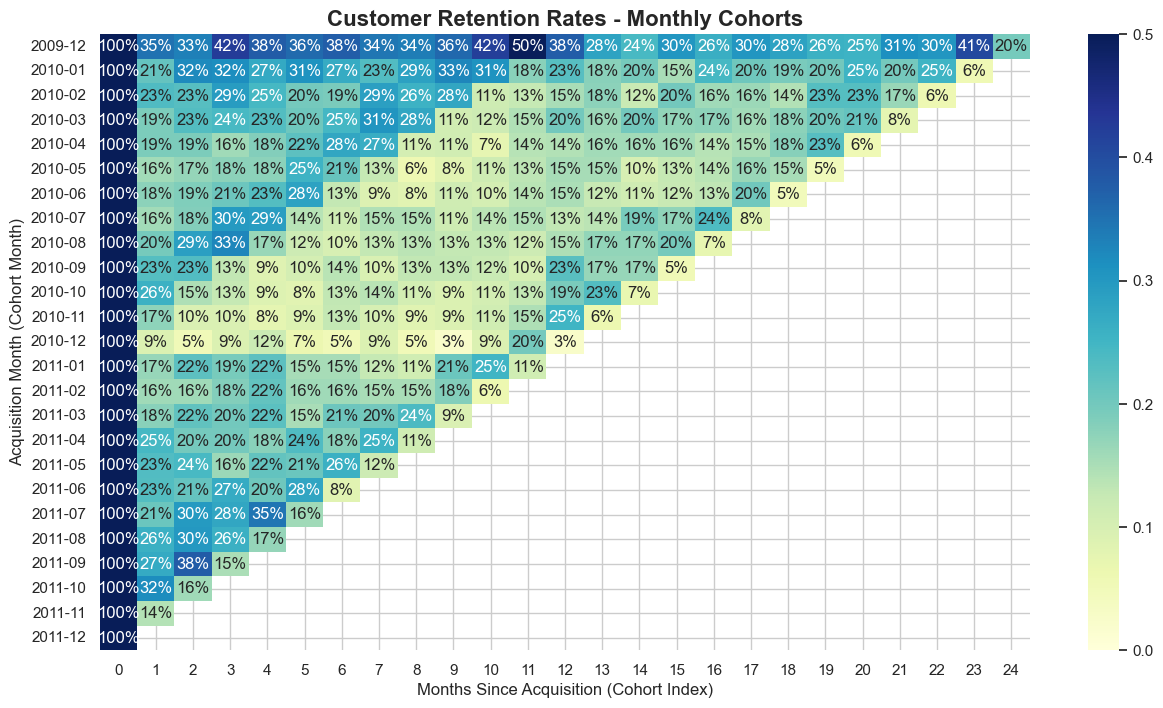

In [18]:
# Define Cohort Month
# Creating a function to truncate dates to the first day of the month
def get_month(x): 
    return dt.datetime(x.year, x.month, 1)

df['InvoiceMonth'] = df['InvoiceDate'].apply(get_month)

# Identify the first purchase month (CohortMonth) for each customer
grouping = df.groupby('Customer ID')['InvoiceMonth']
df['CohortMonth'] = grouping.transform('min')

# Calculate Cohort Index
# Defining a helper function to extract year and month integers
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

# Calculating the difference in months (Cohort Index)
years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

# Index 0 represents the first month, 1 is the following month, etc.
df['CohortIndex'] = years_diff * 12 + months_diff

# Aggregation and Pivoting
# Count unique customers per cohort month and cohort index
grouping = df.groupby(['CohortMonth', 'CohortIndex'])
cohort_data = grouping['Customer ID'].nunique().reset_index()

# Create the pivot table for customer counts
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Calculate Retention Rate
# Dividing each column by the first column (Cohort Size) to get percentages
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# Formatting the index for cleaner visual labels (YYYY-MM)
retention.index = retention.index.strftime('%Y-%m')

# Visualization 
plt.figure(figsize=(15, 8))
plt.title('Customer Retention Rates - Monthly Cohorts', fontsize=16, fontweight='bold')

# Creating the heatmap
sns.heatmap(data=retention, 
            annot=True, 
            fmt='.0%', 
            vmin=0.0, 
            vmax=0.5, 
            cmap='YlGnBu')

plt.xlabel('Months Since Acquisition (Cohort Index)', fontsize=12)
plt.ylabel('Acquisition Month (Cohort Month)', fontsize=12)
plt.show()

### Strategic Evaluation of Cohort Retention Analysis

* The cohort analysis revealed significant volatility in long-term customer commitment. While the initial cohort (Dec 2009) demonstrated a robust retention rate of 50% after 11 months, subsequent cohorts showed a declining trend, stabilizing at a lower average retention rate of approximately 20-25% after the third month. This trend suggests that while acquisition strategies remained functional, the post-purchase engagement mechanisms failed to replicate the high-fidelity loyalty seen in the inception period. The high turnover observed in early indexes implies a necessity for personalized re-engagement campaigns focused on the first 30-60 days of the customer lifecycle to mitigate churn and improve Customer Lifetime Value (CLV).

### 6.4.Predicting Cluster for New Customers
---
The trained model can be used to assign new customers to existing segments based on their RFM values.

In [19]:
def predict_customer_segment(recency, frequency, monetary, scaler, kmeans_model, seg_map=None):
    new_data = np.array([[recency, frequency, monetary]])
    new_data_scaled = scaler.transform(new_data)
    cluster_id = kmeans_model.predict(new_data_scaled)[0]
    segment_name = seg_map.get(cluster_id, "Unknown") if seg_map else "N/A"
    return {"Cluster": cluster_id, "Segment": segment_name}

# --- Example Usage ---

# Use the seg_map we defined earlier based on your RFM profiles
# (Example: {3: 'VIP Customers', 1: 'Loyal Customers', 2: 'Potential Loyalists', 4: 'At Risk/Lost'})
my_seg_map = {
    3: "VIP Customers",
    1: "Loyal Customers", 
    2: "Potential Loyalists",
    4: "At Risk/Lost"
}

# New customer data
new_recency = 10
new_frequency = 15
new_monetary = 5000

result = predict_customer_segment(
    new_recency, new_frequency, new_monetary, scaler, kmeans, seg_map=my_seg_map
)

print(f"--- New Customer Analysis ---")
print(f"Input: R={new_recency}, F={new_frequency}, M={new_monetary}")
print(f"Predicted Cluster: {result['Cluster']}")
print(f"Assigned Segment: {result['Segment']}")

--- New Customer Analysis ---
Input: R=10, F=15, M=5000
Predicted Cluster: 2
Assigned Segment: Potential Loyalists


## Conclusion and Future Work

This study presents a multi-dimensional approach to customer analytics by integrating unsupervised machine learning, dimensionality reduction, and probabilistic lifetime value modeling. The analysis successfully transformed a large-scale transactional dataset into a structured strategic framework.

### Key Findings and Contributions
* **Optimal Segmentation:** Through K-Means clustering, supported by the Elbow Method and Silhouette Analysis, the customer base was segmented into four distinct behavioral groups. This allows for more granular marketing strategies compared to traditional aggregate analysis.
* **Dimensionality Reduction:** The application of **Principal Component Analysis (PCA)** effectively reduced the complexity of the feature space while retaining the most significant variance. This not only improved the computational efficiency of the clustering algorithm but also provided a clearer visualization of customer boundaries.
* **Strategic Value Prediction:** By employing **BG/NBD and Gamma-Gamma models**, the study transcended historical data analysis to provide forward-looking insights. The calculation of **Customer Lifetime Value (CLTV)** enables the business to prioritize resource allocation toward high-potential segments, optimizing the long-term Return on Investment (ROI).
* **Temporal Dynamics:** **Cohort Analysis** revealed critical patterns in customer retention and lifecycle stages, identifying specific time-frames where engagement tends to decline, thus highlighting opportunities for proactive churn prevention.

### Business Implications
The findings suggest that a "one-size-fits-all" marketing approach is inefficient. Instead, the identified **VIP and Loyal** segments should be targeted with retention and loyalty programs, while **Potential Loyalists** require engagement-driven campaigns to increase their purchase frequency. The automated prediction pipeline developed in this project ensures that new customers can be categorized in real-time, allowing for immediate personalized experiences.

### Future Research
Future iterations of this research could incorporate deep learning techniques, such as Recurrent Neural Networks (RNNs), to capture sequential purchase patterns. Additionally, integrating external data points like customer sentiment or demographic details could further refine the accuracy of the segmentation and CLTV predictions.